In [23]:
import pandas as pd
import os

from Bio import Entrez
from Bio.Entrez import efetch

from tqdm import tqdm

from dotenv import load_dotenv
load_dotenv(override=True)

email = os.getenv("ENTREZ_EMAIL")
Entrez.email = email


In [24]:
def get_pub_date(pmid):
    """
    Get publication date from PubMed using PMID.

    :param pmid: PubMed ID
    :return: Publication date in the format {'Year': 'YYYY', 'Month': 'MM', 'Day': 'DD'} or None if not available
    """
    if not isinstance(pmid, int):
        pmid = int(pmid)
    try:
        handle = efetch(db="pubmed", id=pmid, retmode="xml")
        record = Entrez.read(handle)
        handle.close()
        pub_date = record["PubmedArticle"][0]["MedlineCitation"]["Article"]["Journal"]["JournalIssue"]["PubDate"]
        return pub_date
    except Exception as e:
        print(f"Error retrieving PMID {pmid}: {e}")
        return None

# test
print(get_pub_date(20377413))

{'Year': '2010', 'Month': 'May', 'Day': '15'}


# RCT Summarization data

Source: https://github.com/bwallace/RCT-summarization-data

**NOTE**

- The abstracts of each RCT do not include the section headers.
- The inputs may not be the full list of RCTs. Some RCTs may be missing.

*Make sure to download the github repo within the local "data" directory before running the below cells.*

In [ ]:
# TARGET DATA
# the targets are taken as the "Author Conclusions" section from the abstracts of Cochrane 
# (https://www.cochranelibrary.com/) evidence syntheses 

# Load target data from CSV files
train_target_file_path = "./RCT-summarization-data/train-targets.csv"
dev_target_file_path = "./RCT-summarization-data/dev-targets.csv"
test_target_file_path = "./RCT-summarization-data/test-targets.csv"

train_target = pd.read_csv(train_target_file_path)
dev_target = pd.read_csv(dev_target_file_path)
test_target = pd.read_csv(test_target_file_path)

print(f"train_target: {len(train_target)}")
print(f"dev_target: {len(dev_target)}")
print(f"test_target: {len(test_target)}")

# Combine all target dataframes into one
cochrane_data_target = pd.concat([train_target, dev_target, test_target], ignore_index=True)
# We won't be using the 'Unnamed: 0' column, so we drop it
cochrane_data_target = cochrane_data_target.drop(columns=["Unnamed: 0"])
print(f"cochrane_data_target: {len(cochrane_data_target)}")

cochrane_data_target.head()

In [ ]:
# INPUT DATA
# The inputs are titles and abstracts of articles describing randomized controlled trials (RCTs)

# Load input data from CSV files
train_input_file_path = "./RCT-summarization-data/train-inputs.csv"
dev_input_file_path = "./RCT-summarization-data/dev-inputs.csv"
test_input_file_path = "./RCT-summarization-data/test-inputs.csv"

train_input = pd.read_csv(train_input_file_path)
dev_input = pd.read_csv(dev_input_file_path)
test_input = pd.read_csv(test_input_file_path)

print(f"train_input: {len(train_input)}")
print(f"dev_input: {len(dev_input)}")
print(f"test_input: {len(test_input)}")

# Combine all input dataframes into one
cochrane_data_input = pd.concat([train_input, dev_input, test_input], ignore_index=True)
# We won't be using the 'Unnamed: 0' column, so we drop it
cochrane_data_input = cochrane_data_input.drop(columns=["Unnamed: 0"])
print(f"cochrane_data_input: {len(cochrane_data_input)}")

cochrane_data_input.head()

train_input: 40497
dev_input: 5033
test_input: 5678
cochrane_data_input: 51208


,ReviewID,PMID,Title,Abstract
0,CD007697,16394043,Aggressive surgical effort and improved surviv...,Residual disease after initial surgery for ova...
1,CD000174,8627434,Prophylactic indomethacin therapy in the first...,To determine whether a course of low-dose indo...
2,CD000174,2677294,Indomethacin reduces the risks of severe intra...,"A prospective, random selection, double-blind ..."
3,CD000174,3373404,Administration of indomethacin for the prevent...,One hundred twenty-two preterm infants were en...
4,CD000174,3321891,Early intravenous indomethacin prolongs respir...,Infants weighing 1500 g at birth requiring eit...


Add the publication date to each RCT article using the PubMed API.

This takes a bit of time so please be patient...

In [ ]:
# use tqdm to show progress
tqdm.pandas(desc="Retrieving publication dates")

# Apply the get_pub_date function to the PMID column and create a new PubDate column
cochrane_data_input["PubDate"] = cochrane_data_input["PMID"].progress_apply(get_pub_date)

In [ ]:
cochrane_data_input.head()

,ReviewID,PMID,Title,Abstract,PubDate
0,CD007697,16394043,Aggressive surgical effort and improved surviv...,Residual disease after initial surgery for ova...,"{'Year': '2006', 'Month': 'Jan'}"
1,CD000174,8627434,Prophylactic indomethacin therapy in the first...,To determine whether a course of low-dose indo...,"{'Year': '1996', 'Month': 'May'}"
2,CD000174,2677294,Indomethacin reduces the risks of severe intra...,"A prospective, random selection, double-blind ...","{'Year': '1989', 'Month': 'Oct'}"
3,CD000174,3373404,Administration of indomethacin for the prevent...,One hundred twenty-two preterm infants were en...,"{'Year': '1988', 'Month': 'Jun'}"
4,CD000174,3321891,Early intravenous indomethacin prolongs respir...,Infants weighing 1500 g at birth requiring eit...,"{'Year': '1987', 'Month': 'Nov'}"


In [ ]:
# save the cochrane_data_input data to a json file
cochrane_data_input_file_path = "./cochrane_review_data_inputs.jsonl"
cochrane_data_input.to_json(cochrane_data_input_file_path, orient="records", lines=True)
print(f"cochrane review input data saved to {cochrane_data_input_file_path}")

# save the cochrane_data_target data to a json file
cochrane_data_target_file_path = "./cochrane_review_data_targets.jsonl"
cochrane_data_target.to_json(cochrane_data_target_file_path, orient="records", lines=True)
print(f"cochrane review target data saved to {cochrane_data_target_file_path}")

# Simplification Data

Source: https://github.com/AshOlogn/Paragraph-level-Simplification-of-Medical-Texts

**NOTE**

- This is where we will get the full review title and abstract since Summarization Data above only include Author's Conclusion section of each Cochrane Review abstract

*Make sure to download the github repo (specifically the "data" folder) within the local "data" directory before running the below cells.*

In [ ]:
# Cochrane simplification data
simplification_data_file_path = "./Paragraph-level-Simplification-of-Medical-Texts/data.json"
simplification_data = pd.read_json(simplification_data_file_path)

simplification_data.head()

Get the Cochrane ID from the DOI

In [ ]:
# Get DOI column only
simplification_data_doi = simplification_data[["doi"]]
print(f"simplification data: {len(simplification_data_doi)}")

# Remove any duplicates
simplification_data_doi = simplification_data_doi.drop_duplicates()
simplification_data_doi = simplification_data_doi.reset_index(drop=True)
print(f"simplification data after removing duplicates: {len(simplification_data_doi)}")

# Get only the Cochrane ID from the DOI
# split the DOI column on the slash, take the last part, split on the dot, take the second part
simplification_data_doi["doi_slash"] = simplification_data_doi["doi"].str.split("/").str[-1]
simplification_data_doi["cochrane_id"] = simplification_data_doi["doi_slash"].str.split(".").str[1]

# drop the doi_slash column (helper column)
simplification_data_doi = simplification_data_doi.drop(columns=["doi_slash"])

simplification_data_doi.head()


simplification data: 7816
simplification data after removing duplicates: 7816


,doi,cochrane_id
0,10.1002/14651858.CD009997.pub2,CD009997
1,10.1002/14651858.CD006553.pub3,CD006553
2,10.1002/14651858.CD004078.pub2,CD004078
3,10.1002/14651858.CD003957.pub2,CD003957
4,10.1002/14651858.CD003798.pub2,CD003798


In [ ]:
# add cochrane_id to the simplification_data
# merge the simplification_data_doi with the simplification_data on the doi column
simplification_data = simplification_data.merge(simplification_data_doi, left_on="doi", right_on="doi", how="inner")

simplification_data.head()

,doi,name,free,abstract,pls_title,pls_type,pls,cochrane_id
0,10.1002/14651858.CD009997.pub2,Intermittent oral iron supplementation during ...,True,"[{'heading': 'Background', 'text': 'Anaemia is...",Intermittent regimens of iron supplementation ...,long,Anaemia is a frequent condition during pregnan...,CD009997
1,10.1002/14651858.CD006553.pub3,Planned caesarean section for women with a twi...,True,"[{'heading': 'Background', 'text': 'Twin pregn...",Planned caesarean section for a twin pregnancy,long,The incidence of twins varies considerably bet...,CD006553
2,10.1002/14651858.CD004078.pub2,Postoperative adjuvant chemotherapy in rectal ...,True,"[{'heading': 'Background', 'text': 'Colorectal...",Postoperative adjuvant chemotherapy in rectal ...,long,The use of chemotherapy after curative surgery...,CD004078
3,10.1002/14651858.CD003957.pub2,Prophylactic versus selective antibiotics for ...,True,"[{'heading': 'Background', 'text': 'Early onse...",Prophylactic versus selective antibiotics for ...,long,Several factors increase the risk of serious i...,CD003957
4,10.1002/14651858.CD003798.pub2,Specialist outreach clinics in primary care an...,True,"[{'heading': 'Background', 'text': 'Specialist...",Specialist outreach clinics in primary care an...,long,This review examines the benefits and costs of...,CD003798


# Pre-processing Data

Combine Input, Target, and Review Abstract from Simplification Data into One Dataset

In [ ]:
cochrane_data_input_file_path = "./cochrane_review_data_inputs.jsonl"
cochrane_data_target_file_path = "./cochrane_review_data_targets.jsonl"
# load the cochrane_data_input and cochrane_data_target data from json files
cochrane_data_input = pd.read_json(cochrane_data_input_file_path, orient="records", lines=True)
cochrane_data_target = pd.read_json(cochrane_data_target_file_path, orient="records", lines=True)

In [ ]:
cochrane_data = cochrane_data_target.copy()

In [ ]:
# For each row in cochrane_data, get the corresponding number of rows in cochrane_data_input with the same ReviewID
cochrane_data["Inputs"] = cochrane_data["ReviewID"].apply(lambda x: cochrane_data_input[cochrane_data_input["ReviewID"] == x].to_dict(orient="records"))
cochrane_data["NumInputs"] = cochrane_data["Inputs"].apply(lambda x: len(x))
cochrane_data.head()

,ReviewID,Target,Inputs,NumInputs
0,CD007697,We found only low quality evidence comparing u...,"[{'ReviewID': 'CD007697', 'PMID': 16394043, 'T...",1
1,CD000174,Prophylactic indomethacin has short-term benef...,"[{'ReviewID': 'CD000174', 'PMID': 8627434, 'Ti...",14
2,CD008805,First aid for phosphorus burns involves the co...,"[{'ReviewID': 'CD008805', 'PMID': 6024144, 'Ti...",2
3,CD000248,"Compared with control, there was no evidence o...","[{'ReviewID': 'CD000248', 'PMID': 1159434, 'Ti...",4
4,CD004431,The diversity of psychological interventions i...,"[{'ReviewID': 'CD004431', 'PMID': 15240203, 'T...",13


In [ ]:
# Remove reviews with Inputs that have any of PMIDs without PubDate
# This is to ensure that we only keep reviews with valid publication dates
print(f"Number of reviews before removing those with invalid PubDate: {len(cochrane_data)}")
pmids_without_pubdate = [3369327, 18176319, 8019309, 7982870, 9756679, 12237786]
cochrane_data = cochrane_data[~cochrane_data["Inputs"].apply(lambda x: any(input.get("PMID") in pmids_without_pubdate for input in x))]
cochrane_data = cochrane_data.reset_index(drop=True)
print(f"number of reviews with valid publication dates: {len(cochrane_data)}")

Number of reviews before removing those with invalid PubDate: 4692
number of reviews with valid publication dates: 4685


In [ ]:
# STATISTICS

# get the average number of inputs per review
average_num_inputs = cochrane_data["NumInputs"].mean()
print(f"average number of inputs per review: {average_num_inputs}")
# get the maximum number of inputs per review
max_num_inputs = cochrane_data["NumInputs"].max()
print(f"maximum number of inputs per review: {max_num_inputs}")
# get the minimum number of inputs per review
min_num_inputs = cochrane_data["NumInputs"].min()
print(f"minimum number of inputs per review: {min_num_inputs}")

# get the number of reviews with 1 input
num_reviews_with_1_input = cochrane_data[cochrane_data["NumInputs"] == 1].shape[0]
print(f"number of reviews with 1 input: {num_reviews_with_1_input}")

average number of inputs per review: 10.88708644610459
maximum number of inputs per review: 537
minimum number of inputs per review: 1
number of reviews with 1 input: 526


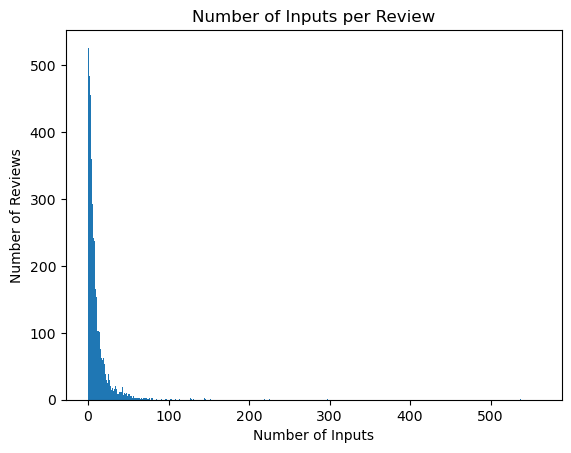

In [ ]:
# create a histogram of the number of inputs per review
import matplotlib.pyplot as plt

plt.hist(cochrane_data["NumInputs"], bins=range(1, max_num_inputs + 25), align="left")
plt.xlabel("Number of Inputs")
plt.ylabel("Number of Reviews")
plt.title("Number of Inputs per Review")

plt.show()

In [ ]:
# grab ReviewID of the reviews with 50+ inputs
cochrane_data_50_inputs = cochrane_data[cochrane_data["NumInputs"] > 50]
cochrane_data_50_inputs = cochrane_data_50_inputs.reset_index(drop=True)
print(f"number of reviews with 50+ inputs: {len(cochrane_data_50_inputs)}")

# # just grab the ReviewID and NumInputs columns
# cochrane_data_50_inputs = cochrane_data_50_inputs[["ReviewID", "NumInputs"]]
# cochrane_data_50_inputs = cochrane_data_50_inputs.reset_index(drop=True)

# # save to jsonl
# cochrane_data_50_inputs_file_path = "./cochrane_review_data_50_inputs_list.jsonl"
# cochrane_data_50_inputs.to_json(cochrane_data_50_inputs_file_path, orient="records", lines=True)

number of reviews with 50+ inputs: 101


In [ ]:
# remove rows with 50+ inputs from the cochrane_data data
cochrane_data = cochrane_data[cochrane_data["NumInputs"] <= 50]
# remove rows with 1 input from the cochrane_data data
cochrane_data = cochrane_data[cochrane_data["NumInputs"] > 1]
cochrane_data = cochrane_data.reset_index(drop=True)
print(f"number of reviews with more than 1 input but less than or equal 50 inputs: {len(cochrane_data)}")

number of reviews with more than 1 input but less than or equal 50 inputs: 4058


In [ ]:
# merge the simplification_data with the cochrane_data data
cochrane_data_merged = cochrane_data.merge(simplification_data, left_on="ReviewID", right_on="cochrane_id", how="inner")
print(f"cochrane_data after merging with simplification data: {len(cochrane_data_merged)}")

# rename the columns doi to DOI and drop cochrane_id
cochrane_data_merged = cochrane_data_merged.rename(columns={"doi": "DOI"})
cochrane_data_merged = cochrane_data_merged.drop(columns=["cochrane_id"])

cochrane_data_merged.head()

In [ ]:
# Cleaning up columns

# Remove the following columns from the cochrane_data_target_merged data: "Target", "free" 
cochrane_data_merged = cochrane_data_merged.drop(columns=["Target", "free", "pls_title", "pls_type", "pls"])

# rename the columns to match the case formatting
cochrane_data_merged = cochrane_data_merged.rename(columns={
    "name": "ReviewTitle",
    "abstract": "ReviewAbstract",
})

# reorder the columns to match the desired output
cochrane_data_merged = cochrane_data_merged[[
    "DOI",
    "ReviewID",
    "ReviewTitle",
    "ReviewAbstract",
    "Inputs",
    "NumInputs"
]]

print(f"Final number of reviews in data: {len(cochrane_data_merged)}")

cochrane_data_merged.head()

Final number of reviews in data: 3913


,DOI,ReviewID,ReviewTitle,ReviewAbstract,Inputs,NumInputs
0,10.1002/14651858.CD000174.pub2,CD000174,Prophylactic intravenous indomethacin for prev...,"[{'heading': 'Background', 'text': 'Persistent...","[{'ReviewID': 'CD000174', 'PMID': 8627434, 'Ti...",14
1,10.1002/14651858.CD008805.pub3,CD008805,Interventions for treating phosphorus burns,"[{'heading': 'Background', 'text': 'Phosphorus...","[{'ReviewID': 'CD008805', 'PMID': 6024144, 'Ti...",2
2,10.1002/14651858.CD000248.pub2,CD000248,Anticoagulants for preventing recurrence follo...,"[{'heading': 'Background', 'text': 'After a fi...","[{'ReviewID': 'CD000248', 'PMID': 1159434, 'Ti...",4
3,10.1002/14651858.CD004431.pub2,CD004431,Psychological interventions for multiple scler...,"[{'heading': 'Background', 'text': 'The unpred...","[{'ReviewID': 'CD004431', 'PMID': 15240203, 'T...",13
4,10.1002/14651858.CD008039.pub3,CD008039,Ibuprofen with or without an antiemetic for ac...,"[{'heading': 'Background', 'text': 'This is an...","[{'ReviewID': 'CD008039', 'PMID': 11554954, 'T...",8


In [ ]:
# STATISTICS
# get the average number of inputs per review
average_num_inputs = cochrane_data_merged["NumInputs"].mean()
print(f"average number of inputs per review: {average_num_inputs}")
# get the maximum number of inputs per review
max_num_inputs = cochrane_data_merged["NumInputs"].max()
print(f"maximum number of inputs per review: {max_num_inputs}")
# get the minimum number of inputs per review
min_num_inputs = cochrane_data_merged["NumInputs"].min()
print(f"minimum number of inputs per review: {min_num_inputs}")

average number of inputs per review: 10.346537183746486
maximum number of inputs per review: 50
minimum number of inputs per review: 2


## Sampling 300 Reviews

We will use this to evaluate the performance of the study number extractor.

In [ ]:
# cochrane_data_sample_300 = cochrane_data_merged.sample(n=300, random_state=1, replace=False)
# # remove Inputs and NumInputs column
# cochrane_data_sample_300 = cochrane_data_sample_300.drop(columns=["Inputs", "NumInputs"])
# # add a new column named "TrueNumInputs" and set it to None
# cochrane_data_sample_300["TrueNumStudies"] = None
# # save the sample to a json file
# cochrane_data_sample_300_file_path = "./cochrane_review_data_300_samples.json"
# cochrane_data_sample_300.to_json(cochrane_data_sample_300_file_path, orient="records", indent=2, force_ascii=False)


# samples_300 = cochrane_data_merged.sample(n=300, replace=False)
# # remove Inputs and NumInputs column
# samples_300 = samples_300.drop(columns=["Inputs", "NumInputs"])
# # add a new column named "TrueNumInputs" and set it to None
# cochrane_data_sample_300["TrueNumStudies"] = None
# # save the sample to a json file
# cochrane_data_sample_300_file_path = "./cochrane_review_data_300_samples.json"

## Intervention Reviews

Use a list of intervention reviews list exported from Cochrane Library to filter out any non-intervention reviews in our dataset.

In [ ]:
# load the citations from the cochrane-intervention-reviews.csv
citations_file_path = "./cochrane-intervention-reviews.csv"
citations = pd.read_csv(citations_file_path)
print(f"number of cochrane intervention reviews citations: {len(citations)}")
citations.head()

number of cochrane intervention reviews citations: 9116


,Cochrane Review ID,Author(s),Title,Source,Year,Abstract,Issue,Publisher,ISSN,Keywords,DOI,URL,Cochrane Review Group Code
0,CD015173.PUB2,"Aung, HH; Naing, C; Ni, H; Aye, SN; Htet, NH; ...",Human stem cells for decompensated cirrhosis i...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,"*Liver Cirrhosis [complications, mortality, su...",10.1002/14651858.CD015173.pub2,http://dx.doi.org/10.1002/14651858.CD015173.pub2,Central Editorial Service
1,CD015376.PUB2,"Vesentini, G; O'Connor, N; Le Berre, M; Nabhan...",Interventions for treating urinary incontinenc...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,NaN,10.1002/14651858.CD015376.pub2,http://dx.doi.org/10.1002/14651858.CD015376.pub2,Central Editorial Service
2,CD004143.PUB6,"Bofill Rodriguez, M; Yong, LN; Mirkov, S; Beko...",Long‐term hormone therapy for perimenopausal a...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,*Estrogen Replacement Therapy [adverse effects...,10.1002/14651858.CD004143.pub6,http://dx.doi.org/10.1002/14651858.CD004143.pub6,Central Editorial Service
3,CD015839.PUB2,"Darlison, P; Moresco, L; Nussbaumer-Streit, B;...",Decongestants and antihistamines for acute oti...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,"*Histamine Antagonists [adverse effects, thera...",10.1002/14651858.CD015839.pub2,http://dx.doi.org/10.1002/14651858.CD015839.pub2,Central Editorial Service
4,CD011852.PUB2,"de Rooij, JD; Verhagen, AP; Harhangi, BS; Fehl...",Nucleoplasty for cervical radicular pain due t...,Cochrane Database of Systematic Reviews,2025,NaN,11,"John Wiley & Sons, Ltd",1465-1858,*Cervical Vertebrae [surgery]; *Intervertebral...,10.1002/14651858.CD011852.pub2,http://dx.doi.org/10.1002/14651858.CD011852.pub2,Central Editorial Service


In [ ]:
# filter the cochrane_data_merged to only include rows where the DOI is in the citations DOI column
cochrane_data_merged = cochrane_data_merged[cochrane_data_merged["DOI"].isin(citations["DOI"])]
cochrane_data_merged = cochrane_data_merged.reset_index(drop=True)
print(f"number of reviews in cochrane_data_merged after filtering with citations: {len(cochrane_data_merged)}")

number of reviews in cochrane_data_merged after filtering with citations: 3430


In [ ]:
# merge the cochrane_data with the citations on the DOI column to add Year and Keywords
cochrane_data_merged = cochrane_data_merged.merge(citations[["DOI", "Year", "Keywords"]], on="DOI", how="left")
cochrane_data_merged.head()

,DOI,ReviewID,ReviewTitle,ReviewAbstract,Inputs,NumInputs,Year,Keywords
0,10.1002/14651858.CD000174.pub2,CD000174,Prophylactic intravenous indomethacin for prev...,"[{'heading': 'Background', 'text': 'Persistent...","[{'ReviewID': 'CD000174', 'PMID': 8627434, 'Ti...",14,2010,"*Infant, Very Low Birth Weight; Cardiovascular..."
1,10.1002/14651858.CD008805.pub3,CD008805,Interventions for treating phosphorus burns,"[{'heading': 'Background', 'text': 'Phosphorus...","[{'ReviewID': 'CD008805', 'PMID': 6024144, 'Ti...",2,2014,"*Phosphorus; Antidotes [adverse effects, *ther..."
2,10.1002/14651858.CD000248.pub2,CD000248,Anticoagulants for preventing recurrence follo...,"[{'heading': 'Background', 'text': 'After a fi...","[{'ReviewID': 'CD000248', 'PMID': 1159434, 'Ti...",4,2009,"Anticoagulants [adverse effects, *therapeutic ..."
3,10.1002/14651858.CD004431.pub2,CD004431,Psychological interventions for multiple scler...,"[{'heading': 'Background', 'text': 'The unpred...","[{'ReviewID': 'CD004431', 'PMID': 15240203, 'T...",13,2006,"*Adaptation, Psychological; Cognition Disorder..."
4,10.1002/14651858.CD008039.pub3,CD008039,Ibuprofen with or without an antiemetic for ac...,"[{'heading': 'Background', 'text': 'This is an...","[{'ReviewID': 'CD008039', 'PMID': 11554954, 'T...",8,2013,"Administration, Oral; Adult; Analgesics, Non‐N..."


In [ ]:
# get number of unique PubMedIDs in the Inputs
unique_pubmed_ids = set()
for inputs in cochrane_data_merged["Inputs"]:
    for input in inputs:
        pmid = input.get("PMID")
        if pmid:
            unique_pubmed_ids.add(pmid)

print(f"number of unique PubMedIDs in the Inputs: {len(unique_pubmed_ids)}")

number of unique PubMedIDs in the Inputs: 32181


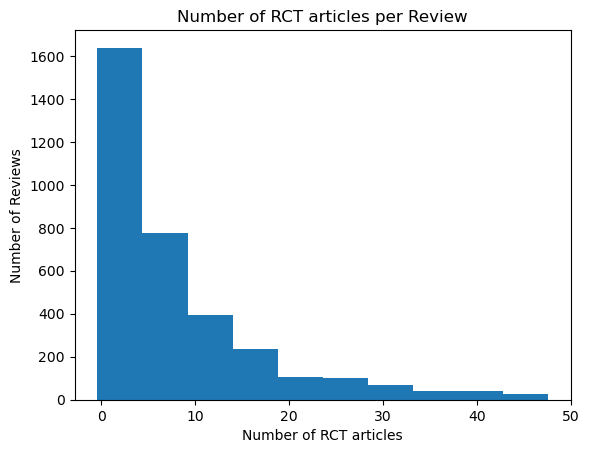

In [ ]:
# create a histogram of the number of inputs per review
import matplotlib.pyplot as plt

plt.hist(cochrane_data_merged["NumInputs"], align="left")
plt.xlabel("Number of RCT articles")
plt.ylabel("Number of Reviews")
plt.title("Number of RCT articles per Review")

# save the figure as PDF
# plt.savefig("num_rcts_per_review.pdf")

plt.show()

In [28]:
# get highest and lowest year from the Year column
years = cochrane_data_merged["Year"].astype(int)
highest_year = years.max()
lowest_year = years.min()
print(f"highest year in the data: {highest_year}")
print(f"lowest year in the data: {lowest_year}")

highest year in the data: 2020
lowest year in the data: 1997


In [ ]:
samples = pd.read_json("./cochrane_review_data_300_samples.json")

# how many match from cochrane_data_merged
matched_samples = samples[samples["ReviewID"].isin(cochrane_data_merged["ReviewID"])]
print(f"number of matched samples from cochrane_data_merged: {len(matched_samples)}")

number of matched samples from cochrane_data_merged: 269


In [ ]:
# save the cochrane_review_data data to a jsonl file
cochrane_data_file_path = "./cochrane_review_data.jsonl"
cochrane_data_merged.to_json(cochrane_data_file_path, orient="records", lines=True, force_ascii=False)
print(f"fully merged cochrane review data saved to {cochrane_data_file_path}")

fully merged cochrane review data saved to ./cochrane_review_data.jsonl


# Annotation - Number of Studies - Check

In [29]:
import pandas as pd

ac_annotated = pd.read_json("cochrane_review_data_300_samples_ac_annotated.json")
print(f"number of annotated samples: {len(ac_annotated)}")
hl_annotated = pd.read_json("cochrane_review_data_300_samples_hl_annotated.json")
print(f"number of annotated samples: {len(hl_annotated)}")

number of annotated samples: 300
number of annotated samples: 300


In [30]:
# compare TrueNumStudies column from both dataframes and find mismatches
mismatches = []
for _, row in ac_annotated.iterrows():
    review_id = row["ReviewID"]
    true_num_studies_ac = row["TrueNumStudies"]
    true_num_studies_hl = hl_annotated[hl_annotated["ReviewID"] == review_id]["TrueNumStudies"].values
    if len(true_num_studies_hl) == 0:
        continue
    true_num_studies_hl = true_num_studies_hl[0]
    if true_num_studies_ac != true_num_studies_hl:
        mismatches.append((review_id, true_num_studies_ac, true_num_studies_hl))

In [32]:
# print mismatches
print(f"Mismatches in TrueNumStudies between AC and HL annotations: {len(mismatches)}")
for mismatch in mismatches:
    print(f"Mismatch for ReviewID {mismatch[0]}: AC TrueNumStudies = {mismatch[1]}, HL TrueNumStudies = {mismatch[2]}")

Mismatches in TrueNumStudies between AC and HL annotations: 13
Mismatch for ReviewID CD000512: AC TrueNumStudies = 5, HL TrueNumStudies = 4
Mismatch for ReviewID CD003545: AC TrueNumStudies = 50, HL TrueNumStudies = 13
Mismatch for ReviewID CD001244: AC TrueNumStudies = 41, HL TrueNumStudies = 36
Mismatch for ReviewID CD001990: AC TrueNumStudies = 5, HL TrueNumStudies = 6
Mismatch for ReviewID CD006148: AC TrueNumStudies = 19, HL TrueNumStudies = 17
Mismatch for ReviewID CD001860: AC TrueNumStudies = 26, HL TrueNumStudies = 14
Mismatch for ReviewID CD002760: AC TrueNumStudies = 4, HL TrueNumStudies = 52
Mismatch for ReviewID CD007712: AC TrueNumStudies = 4, HL TrueNumStudies = 3
Mismatch for ReviewID CD007400: AC TrueNumStudies = 39, HL TrueNumStudies = 5
Mismatch for ReviewID CD004251: AC TrueNumStudies = 20, HL TrueNumStudies = 22
Mismatch for ReviewID CD007045: AC TrueNumStudies = 2, HL TrueNumStudies = 1
Mismatch for ReviewID CD003869: AC TrueNumStudies = 54, HL TrueNumStudies = 10

# END

# Sampling

In [ ]:
cochrane_data_final_file_path = "./cochrane_review_data_final.jsonl"
cochrane_data_final = pd.read_json(cochrane_data_final_file_path, orient="records", lines=True)
# sample 50 reviews from the cochrane_data_final
cochrane_data_sample = cochrane_data_final.sample(n=50, random_state=1, replace=False)
# save the sample to a jsonl file
cochrane_data_sample_file_path = "./cochrane_review_data_50_sample_q_gen.jsonl"
cochrane_data_sample.to_json(cochrane_data_sample_file_path, orient="records", lines=True, force_ascii=False)

In [ ]:
# sampling 300 review from the cochrane_data_final
cochrane_data_final_file_path = "./cochrane_review_data_final.jsonl"
cochrane_data_final = pd.read_json(cochrane_data_final_file_path, orient="records", lines=True)
# sample 300 reviews from the cochrane_data_final
cochrane_data_sample_300 = cochrane_data_final.sample(n=300, random_state=1, replace=False)
# remove Inputs and NumInputs column
cochrane_data_sample_300 = cochrane_data_sample_300.drop(columns=["Inputs", "NumInputs"])
# add a new column named "TrueNumInputs" and set it to None
cochrane_data_sample_300["TrueNumStudies"] = None
# save the sample to a json file
cochrane_data_sample_300_file_path = "./cochrane_review_data_300_samples.json"
cochrane_data_sample_300.to_json(cochrane_data_sample_300_file_path, orient="records", indent=2, force_ascii=False)

In [19]:
# sampling 10 review from cochrane_data_final for annotation_sample
cochrane_data_annotation_sample_file_path = "./cochrane_review_data_samples_annotated.json"
cochrane_data_annotation_sample = cochrane_data_final.sample(n=10, random_state=2, replace=False)
# remove Inputs and NumInputs column
cochrane_data_annotation_sample = cochrane_data_annotation_sample.drop(columns=["Inputs", "NumInputs"])
# add a new column named "TrueNumInputs" and set it to None
cochrane_data_annotation_sample["TrueNumStudies"] = None
cochrane_data_annotation_sample.to_json(cochrane_data_annotation_sample_file_path, orient="records", indent=2, force_ascii=False)

# MedReadMe

readability dataset used to train the roberta large model that predicts the readability score.

In [2]:
# load readability.csv file
import pandas as pd
readability_file_path = "./readability.csv"
readability = pd.read_csv(readability_file_path)
print(f"readability number of rows: {len(readability)}")

# get the average, maximum, minimum, median, and standard deviation of the Readability column
average_readability = readability["Readability"].mean()
max_readability = readability["Readability"].max()
min_readability = readability["Readability"].min()
median_readability = readability["Readability"].median()
std_readability = readability["Readability"].std()

# Get the quartiles of the 'Readability' column
quartiles = readability['Readability'].quantile([0.25, 0.5, 0.75])

print(f"average readability: {average_readability}")
print(f"maximum readability: {max_readability}")
print(f"minimum readability: {min_readability}")
print(f"median readability: {median_readability}")
print(f"standard deviation of readability: {std_readability}")
print(f"Readability quartiles:\n{quartiles}")

readability number of rows: 4504
average readability: 4.23959813499112
maximum readability: 6.0
minimum readability: 1.0
median readability: 4.3
standard deviation of readability: 0.7785708638060174
Readability quartiles:
0.25    3.7
0.50    4.3
0.75    4.7
Name: Readability, dtype: float64


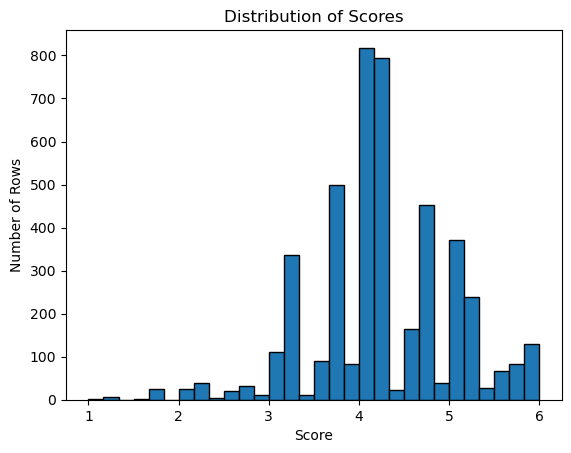

In [5]:
# histogram of the Readability column
import matplotlib.pyplot as plt
plt.hist(readability["Readability"], bins=30, edgecolor='black')
plt.xlabel("Score")
plt.ylabel("Number of Rows")
plt.title("Distribution of Scores")
plt.show()

# Stats

In [9]:
question_types = ["effectiveness1", "effectiveness2", "safety", "studies", "timepressure",
                                  "cost", "family", "friend", "testimonials", "journals", "llm", "doctor"]

for question_type in question_types:
    input_file_path = f"../code/outputs/improved_scored_questions/llama3.3_instruct_70B/{question_type}_questions_with_readability_scores_improved_questions_with_readability_scores.json"
    
    print(f"Processing file: {input_file_path}")
     # load the data
    data = pd.read_json(input_file_path, orient="records")
    print(f"data: {len(data)}")
    results = []

    for index, item in data.iterrows():
        # change item to a dictionary
        item = item.to_dict()
        if 'MedReadMeScore' in item and 'ImprovedMedReadMeScore' in item:
            positive_question_score = item["ImprovedMedReadMeScore"]["positive"] - item["MedReadMeScore"]["positive"]
            negative_question_score = item["ImprovedMedReadMeScore"]["negative"] - item["MedReadMeScore"]["negative"]
            item["ImprovementScore"] = {
                "positive": positive_question_score,
                "negative": negative_question_score
            }
            results.append(item)
        else:
            continue

    # save the results to file with same name
    # use json to save the results
    import json
    with open(input_file_path, "w", encoding='utf-8') as file:
        json.dump(results, file, indent=4)

Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/effectiveness1_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 33
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/effectiveness2_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 33
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/safety_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 34
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/studies_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 29
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/timepressure_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 29
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/c

In [10]:
# get average improvement for positive and negative
# get median improvement for positive and negative
# get maximum improvement for positive and negative
# get minimum improvement for positive and negative
# get standard deviation of improvement for positive and negative

#merge all the files into one dataframe
all_results = []
for question_type in question_types:
    input_file_path = f"../code/outputs/improved_scored_questions/llama3.3_instruct_70B/{question_type}_questions_with_readability_scores_improved_questions_with_readability_scores.json"
    print(f"Processing file: {input_file_path}")
     # load the data
    data = pd.read_json(input_file_path, orient="records")
    print(f"data: {len(data)}")
    all_results.append(data)
all_results_df = pd.concat(all_results, ignore_index=True)
print(f"all_results_df: {len(all_results_df)}")

# get average improvement for positive and negative
average_improvement_positive = all_results_df["ImprovementScore"].apply(lambda x: x["positive"]).mean()
average_improvement_negative = all_results_df["ImprovementScore"].apply(lambda x: x["negative"]).mean()
print(f"average improvement positive: {average_improvement_positive}")
print(f"average improvement negative: {average_improvement_negative}")

# get median improvement for positive and negative
median_improvement_positive = all_results_df["ImprovementScore"].apply(lambda x: x["positive"]).median()
median_improvement_negative = all_results_df["ImprovementScore"].apply(lambda x: x["negative"]).median()
print(f"median improvement positive: {median_improvement_positive}")
print(f"median improvement negative: {median_improvement_negative}")

# get maximum improvement for positive and negative
max_improvement_positive = all_results_df["ImprovementScore"].apply(lambda x: x["positive"]).max()
max_improvement_negative = all_results_df["ImprovementScore"].apply(lambda x: x["negative"]).max()
print(f"maximum improvement positive: {max_improvement_positive}")
print(f"maximum improvement negative: {max_improvement_negative}")

# get minimum improvement for positive and negative
min_improvement_positive = all_results_df["ImprovementScore"].apply(lambda x: x["positive"]).min()
min_improvement_negative = all_results_df["ImprovementScore"].apply(lambda x: x["negative"]).min()
print(f"minimum improvement positive: {min_improvement_positive}")
print(f"minimum improvement negative: {min_improvement_negative}")

# get standard deviation of improvement for positive and negative
std_improvement_positive = all_results_df["ImprovementScore"].apply(lambda x: x["positive"]).std()
std_improvement_negative = all_results_df["ImprovementScore"].apply(lambda x: x["negative"]).std()
print(f"standard deviation of improvement positive: {std_improvement_positive}")
print(f"standard deviation of improvement negative: {std_improvement_negative}")

Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/effectiveness1_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 33
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/effectiveness2_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 33
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/safety_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 34
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/studies_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 29
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/timepressure_questions_with_readability_scores_improved_questions_with_readability_scores.json
data: 29
Processing file: ../code/outputs/improved_scored_questions/llama3.3_instruct_70B/c

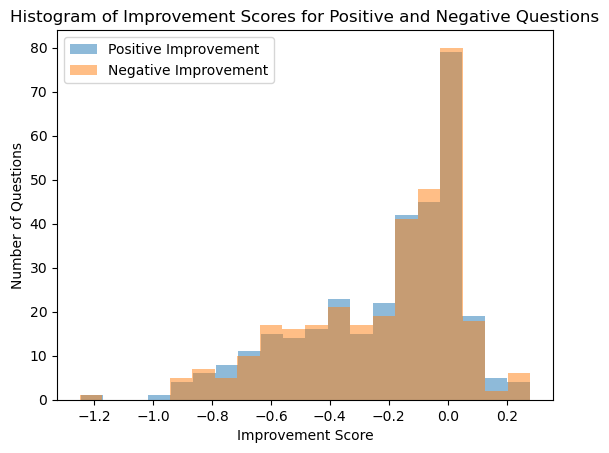

In [11]:
# create histogram of improvement for positive and negative
import matplotlib.pyplot as plt

plt.hist(all_results_df["ImprovementScore"].apply(lambda x: x["positive"]), bins=20, alpha=0.5, label="Positive Improvement")
plt.hist(all_results_df["ImprovementScore"].apply(lambda x: x["negative"]), bins=20, alpha=0.5, label="Negative Improvement")
plt.xlabel("Improvement Score")
plt.ylabel("Number of Questions")
plt.title("Histogram of Improvement Scores for Positive and Negative Questions")
plt.legend()
plt.show()

# Extracting Number of Studies from Review Abstracts

In [5]:
# read following list of files and print Cochrane Review IDs where LLMExtractedNumStudies is not equal to TrueNumStudies
files_to_check = ["cochrane_review_data_300_samples_annotated_ac_with_llama3.json", "cochrane_review_data_300_samples_annotated_ac_with_gpt4.json", "cochrane_review_data_300_samples_annotated_ac_with_claude4.json"]
review_ids_mismatch = []
for file in files_to_check:
    print(f"Processing file: {file}")
     # load the data
    data = pd.read_json(file, orient="records")
    print(f"data: {len(data)}")
    for index, item in data.iterrows():
        if item["LLMExtractedNumStudies"] != item["TrueNumStudies"]:
            print(f"ReviewID: {item['ReviewID']}, LLMExtractedNumStudies: {item['LLMExtractedNumStudies']}, TrueNumStudies: {item['TrueNumStudies']}")
            review_ids_mismatch.append(item['ReviewID'])

print(f"Number of ReviewIDs with discrepancies in total across 3 models: {len(review_ids_mismatch)}")
review_ids_mismatch = list(set(review_ids_mismatch))
print(f"Number of unique ReviewIDs with discrepancies: {len(review_ids_mismatch)}")

for review_id in review_ids_mismatch:
    print(review_id)

Processing file: cochrane_review_data_300_samples_annotated_ac_with_llama3.json
data: 300
ReviewID: CD000512, LLMExtractedNumStudies: 4, TrueNumStudies: 5
ReviewID: CD003545, LLMExtractedNumStudies: 49, TrueNumStudies: 50
ReviewID: CD002856, LLMExtractedNumStudies: 5, TrueNumStudies: 4
ReviewID: CD005479, LLMExtractedNumStudies: 15, TrueNumStudies: 1
ReviewID: CD004168, LLMExtractedNumStudies: 15, TrueNumStudies: 11
ReviewID: CD006148, LLMExtractedNumStudies: 17, TrueNumStudies: 19
ReviewID: CD000308, LLMExtractedNumStudies: 8, TrueNumStudies: 2
ReviewID: CD006052, LLMExtractedNumStudies: 2, TrueNumStudies: 1
ReviewID: CD008975, LLMExtractedNumStudies: 7, TrueNumStudies: 3
Processing file: cochrane_review_data_300_samples_annotated_ac_with_gpt4.json
data: 300
ReviewID: CD006268, LLMExtractedNumStudies: 23, TrueNumStudies: 22
ReviewID: CD003545, LLMExtractedNumStudies: 63, TrueNumStudies: 50
ReviewID: CD003004, LLMExtractedNumStudies: 7, TrueNumStudies: 5
ReviewID: CD001244, LLMExtracte

In [1]:
# read cochrane_review_data_300_samples.json and add empty list for AnnotationAnswerAttribution key
import pandas as pd

cochrane_data_300_samples_file_path = "./cochrane_review_data_300_samples.json"
cochrane_data_300_samples = pd.read_json(cochrane_data_300_samples_file_path, orient="records")
# add empty list for AnnotationAnswerAttribution key
cochrane_data_300_samples["AnnotationAnswerAttribution"] = [[] for _ in range(len(cochrane_data_300_samples))]
# save to same file
cochrane_data_300_samples.to_json(cochrane_data_300_samples_file_path, orient="records", indent=2, force_ascii=False)
print(f"cochrane review data with AnnotationAnswerAttribution key added saved to {cochrane_data_300_samples_file_path}")

# read cochrane_review_data_samples_annotated.json and add AnnotationAnswerAttribution with empty list as value
cochrane_data_samples_annotated_file_path = "./cochrane_review_data_samples_annotated.json"
cochrane_data_samples_annotated = pd.read_json(cochrane_data_samples_annotated_file_path, orient="records")
# add empty list for AnnotationAnswerAttribution key
cochrane_data_samples_annotated["AnnotationAnswerAttribution"] = [[] for _ in range(len(cochrane_data_samples_annotated))]
# save to same file
cochrane_data_samples_annotated.to_json(cochrane_data_samples_annotated_file_path, orient="records", indent=2, force_ascii=False)
print(f"cochrane review data with AnnotationAnswerAttribution key added saved to {cochrane_data_samples_annotated_file_path}")

cochrane review data with AnnotationAnswerAttribution key added saved to ./cochrane_review_data_300_samples.json
cochrane review data with AnnotationAnswerAttribution key added saved to ./cochrane_review_data_samples_annotated.json


# Filtering for Nutrition, Diet, and Exercise related Reviews

In [6]:
import re
import json
from tqdm import tqdm

In [2]:
def format_review_abstract(review_abstract_sections: list) -> str:
    """
    This method formats the review abstract to ensure it is just a string of all headers with corresponding text.

    :param review_abstract: The raw review abstract sections in a list
    :return: Formatted review abstract
    """
    formatted_abstract = ""
    # iterate through the sections and format them
    for section in review_abstract_sections:
        heading = section["heading"]
        text = section["text"]
        formatted_abstract += f"{heading}: {text}\n"
    return formatted_abstract.strip()

def load_jsonl_file(file_path: str) -> list[dict]:
    """
    This method loads a JSONL file and returns the data as a list of dictionaries

    :param file_path: path to the JSONL file

    :return data as a list of dictionaries
    """
    data = []
    with open(file_path, "r", encoding="utf-8-sig") as file:
        for line in file:
            data.append(json.loads(line))
    return data

def save_dataset_to_json(dataset: list[dict], file_path: str, jsonl: bool = False, columns_to_drop: list[str] | None = None) -> None:
    """
    This method saves a dataset (dictionary) in json file to the data folder

    :param dataset: dataset to save
    :param file_path: name of the dataset to save
    :param jsonl: whether to save as jsonl file
    :param columns_to_drop: list of columns to drop from the dataset before saving
    """
    if columns_to_drop is not None:
        dataset = [{k: v for k, v in d.items() if k not in columns_to_drop} for d in dataset]
    with open(file_path, "w", encoding='utf-8') as file:
        if jsonl:
            for entry in dataset:
                file.write(json.dumps(entry) + "\n")
        else:
            json.dump(dataset, file, indent=4)

In [3]:
cochrane_data_final_file_path = "./cochrane_review_data_final.jsonl"
cochrane_data_final = load_jsonl_file(cochrane_data_final_file_path)

-  Root terms: nutrition, diet, dietary, exercise
-  Interventions: fasting, caloric restriction, supplementation, fortification
-  Specific Diets: Mediterranean, DASH, keto, vegan, low-carb
-  Micro/Macro Nutrients: vitamin D, iron, protein, fatty acid, carbohydrate, fiber
-  Related Conditions: obesity, malnutrition, overweight, scurvy, anemia (in a nutritional context)

In [ ]:
keywords = [
    "nutrition", "diet", "dietary", "fasting", "caloric restriction", "food",
    "supplementation", "nutrient",
    "vitamin", "iron", "protein", "fatty acid", "carbohydrate", "fiber",
    "obesity", "malnutrition", "mediterranean diet", "low-carb", "intake",
    "overweight", "undernutrition", "eating habits",
    "appetite", "metabolism", "weight loss", "body mass index",
    "exercise", "physical activity", "sedentary lifestyle", "fitness",
    "aerobic", "anaerobic", "strength training",
    "endurance", "flexibility", "body composition", "muscle mass",
    "cardio", "workout", "sedentary", "movement"
]

In [7]:
# This creates a single pattern like: (nutrition|diet|dietary|...|intake)
# \b ensures we match whole words only (e.g., 'diet' not 'diabetic')
pattern = r'\b(' + '|'.join(re.escape(k) for k in keywords) + r')\b'

# We compile it for efficiency and make it case-insensitive
keyword_regex = re.compile(pattern, re.IGNORECASE)

matched_reviews = []
pbar = tqdm(cochrane_data_final, desc="Filtering with Simple Regex")
for _, item in enumerate(pbar):
    # list of dictionaries with following keys:
    # 'ReviewID', 'DOI', 'ReviewTitle', 'ReviewAbstract', 'Inputs', 'NumInputs'
    review_abstract_sections = item["ReviewAbstract"]
    formatted_abstract = format_review_abstract(review_abstract_sections)

    # Use re.search() to find the first match
    if keyword_regex.search(formatted_abstract):
        print(keyword_regex.search(formatted_abstract).group())
        matched_reviews.append(item)
        print(f"MATCH (ID: {item['ReviewID']}): Found a keyword in abstract.")

print(f"\nTotal found: {len(matched_reviews)} out of {len(cochrane_data_final)}")
    

Filtering with Simple Regex:  31%|███       | 1176/3814 [00:00<00:00, 5951.74it/s]

Vitamin
MATCH (ID: CD006164): Found a keyword in abstract.
Obesity
MATCH (ID: CD004931): Found a keyword in abstract.
Food
MATCH (ID: CD008341): Found a keyword in abstract.
metabolism
MATCH (ID: CD003685): Found a keyword in abstract.
intake
MATCH (ID: CD006273): Found a keyword in abstract.
protein
MATCH (ID: CD002997): Found a keyword in abstract.
weight loss
MATCH (ID: CD002309): Found a keyword in abstract.
supplementation
MATCH (ID: CD007368): Found a keyword in abstract.
dietary
MATCH (ID: CD001015): Found a keyword in abstract.
undernutrition
MATCH (ID: CD003517): Found a keyword in abstract.
diet
MATCH (ID: CD005230): Found a keyword in abstract.
Vitamin
MATCH (ID: CD004069): Found a keyword in abstract.
vitamin
MATCH (ID: CD004923): Found a keyword in abstract.
iron
MATCH (ID: CD007476): Found a keyword in abstract.
fasting
MATCH (ID: CD005285): Found a keyword in abstract.
intake
MATCH (ID: CD005032): Found a keyword in abstract.
intake
MATCH (ID: CD008205): Found a keyword 

Filtering with Simple Regex:  63%|██████▎   | 2408/3814 [00:00<00:00, 5833.32it/s]

intake
MATCH (ID: CD003216): Found a keyword in abstract.
dietary
MATCH (ID: CD004077): Found a keyword in abstract.
Vitamin
MATCH (ID: CD004393): Found a keyword in abstract.
intake
MATCH (ID: CD009350): Found a keyword in abstract.
dietary
MATCH (ID: CD003395): Found a keyword in abstract.
Vitamin
MATCH (ID: CD000501): Found a keyword in abstract.
nutrition
MATCH (ID: CD007536): Found a keyword in abstract.
diet
MATCH (ID: CD008788): Found a keyword in abstract.
weight loss
MATCH (ID: CD008650): Found a keyword in abstract.
supplementation
MATCH (ID: CD008611): Found a keyword in abstract.
protein
MATCH (ID: CD003965): Found a keyword in abstract.
diet
MATCH (ID: CD003286): Found a keyword in abstract.
carbohydrate
MATCH (ID: CD004467): Found a keyword in abstract.
appetite
MATCH (ID: CD007524): Found a keyword in abstract.
intake
MATCH (ID: CD002826): Found a keyword in abstract.
body mass index
MATCH (ID: CD003531): Found a keyword in abstract.
intake
MATCH (ID: CD004282): Found a 

Filtering with Simple Regex: 100%|██████████| 3814/3814 [00:00<00:00, 6052.24it/s]

diet
MATCH (ID: CD006401): Found a keyword in abstract.
nutrient
MATCH (ID: CD000366): Found a keyword in abstract.
weight loss
MATCH (ID: CD007654): Found a keyword in abstract.
obesity
MATCH (ID: CD003002): Found a keyword in abstract.
malnutrition
MATCH (ID: CD008901): Found a keyword in abstract.
protein
MATCH (ID: CD007514): Found a keyword in abstract.
dietary
MATCH (ID: CD001304): Found a keyword in abstract.
vitamin
MATCH (ID: CD006466): Found a keyword in abstract.
dietary
MATCH (ID: CD004192): Found a keyword in abstract.
intake
MATCH (ID: CD004662): Found a keyword in abstract.
nutrition
MATCH (ID: CD007615): Found a keyword in abstract.
intake
MATCH (ID: CD007715): Found a keyword in abstract.
supplementation
MATCH (ID: CD000375): Found a keyword in abstract.
nutrition
MATCH (ID: CD003353): Found a keyword in abstract.
metabolism
MATCH (ID: CD001776): Found a keyword in abstract.
vitamin
MATCH (ID: CD000990): Found a keyword in abstract.
Dietary
MATCH (ID: CD003205): Found 

In [ ]:
save_dataset_to_json(matched_reviews, "./cochrane_review_data_nutrition_diet_exercise_related.json")